# Import libraries and load dataset

The jupyter notebook have been created and executed in Google Colab;
As such, make sure the file path is changed accordingly to the tool used.
Below the list of libraries we have used.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# libraries for preprocessing
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
!pip install category-encoders
from category_encoders import TargetEncoder

# libraries for model training
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
!pip install h2o
import h2o
from h2o.estimators import H2ORandomForestEstimator
import tensorflow as tf
from tensorflow import keras
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# libraries for model metrics
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve

# libraries for visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.tree import export_graphviz
import graphviz

# libraries for web implementation
!pip install streamlit
import streamlit as st
import joblib
!npm install localtunnel

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.3/265.3 MB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for h2o: filename=h2o-3.46.0.2-py2.py3-none-any.whl size=265365378 sha256=9fc040796f9419e14c2a1362b7c573f8d7da535c53a307f7505e4a12b19cc8b4
  Stored in directory: /root/.cache/pip/wheels/63/14/f4/9fff736a0df59884631031b604e7b000a70409f5b7adafc2c6
Successfully built h2o
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 37.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 21.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 86.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.0/83.0 kB 11.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 8.6 MB/s eta 0:00:00
npm WARN saveError ENOENT: no such file or directory, open '/content/package.json'
npm notice created a lockfi

In [3]:
# change path to the directory where luiss_data_anonym.xlsx is located
path = '/content/drive/MyDrive/ML Project/luiss_data_anonym.xlsx'
data = pd.read_excel(path, index_col=0)

# EDA
A brief exploratory data analysis prior to data cleaning and preprocessing to determine missing values, unmapped values, columns to be excluded, and target variable class imbalance

In [ ]:
data.head(5)

,A,Ateco,B,C,DataDoc,D,E,F,G,H,...,Rev,CVia,Rifamm,X,Art2,Valore2,Art3,Valore3,TIva,Caus
1,7,476220,N,NaN,2022-08-09,I,NaN,NaN,NaN,NaN,...,NaN,N,NaN,N,NaN,NaN,NaN,NaN,12,12
2,7,476220,N,NaN,2022-08-09,I,NaN,NaN,NaN,NaN,...,NaN,N,NaN,N,NaN,NaN,NaN,NaN,12,12
3,7,476220,N,NaN,2022-08-09,I,NaN,NaN,NaN,NaN,...,NaN,N,NaN,N,NaN,NaN,NaN,NaN,12,12
4,7,476220,N,NaN,2022-08-09,I,NaN,NaN,NaN,NaN,...,NaN,N,NaN,N,NaN,NaN,NaN,NaN,12,12
5,7,476220,N,NaN,2022-08-09,I,NaN,NaN,NaN,NaN,...,NaN,N,NaN,N,NaN,NaN,NaN,NaN,12,12


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 134437 entries, 1 to 234501
Data columns (total 44 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   A                134437 non-null  object        
 1   Ateco            134437 non-null  int64         
 2   B                134383 non-null  object        
 3   C                8757 non-null    float64       
 4   DataDoc          134437 non-null  datetime64[ns]
 5   D                134436 non-null  object        
 6   E                1795 non-null    object        
 7   F                1795 non-null    object        
 8   G                19 non-null      object        
 9   H                19 non-null      object        
 10  Tdoc             134437 non-null  object        
 11  VA               134437 non-null  object        
 12  CE               2091 non-null    object        
 13  DescrizioneRiga  133814 non-null  object        
 14  Importo          134437 n

By checking the original dataset shape, we observe that there are ~135000 invoices and 44 variables

In [ ]:
data.shape

(134437, 44)

We returned the null value count across all variables in the dataset. To better visualize the missing values in each variable, we generated a heatmap, where dark blue indicates a missing value.

In [ ]:
null_data = data.isnull()
null_data.sum()

A                       0
Ateco                   0
B                      54
C                  125680
DataDoc                 0
D                       1
E                  132642
F                  132642
G                  134418
H                  134418
Tdoc                    0
VA                      0
CE                 132346
DescrizioneRiga       623
Importo                 0
Iva                     0
Conto                   0
ContoStd                0
IvaM                  471
Comp               134437
Iva11              100624
TM                      0
%Forf              134402
Art1                   48
Valore1                 0
Nomenclatura       134416
Ritac              133706
RF                  79149
%RIT1                   0
%RIT2                   0
CoDitta                 0
RifNormativo        71485
CMar                  403
CTra                   84
Rev                  1657
CVia                    0
Rifamm             132846
X                    4465
Art2        

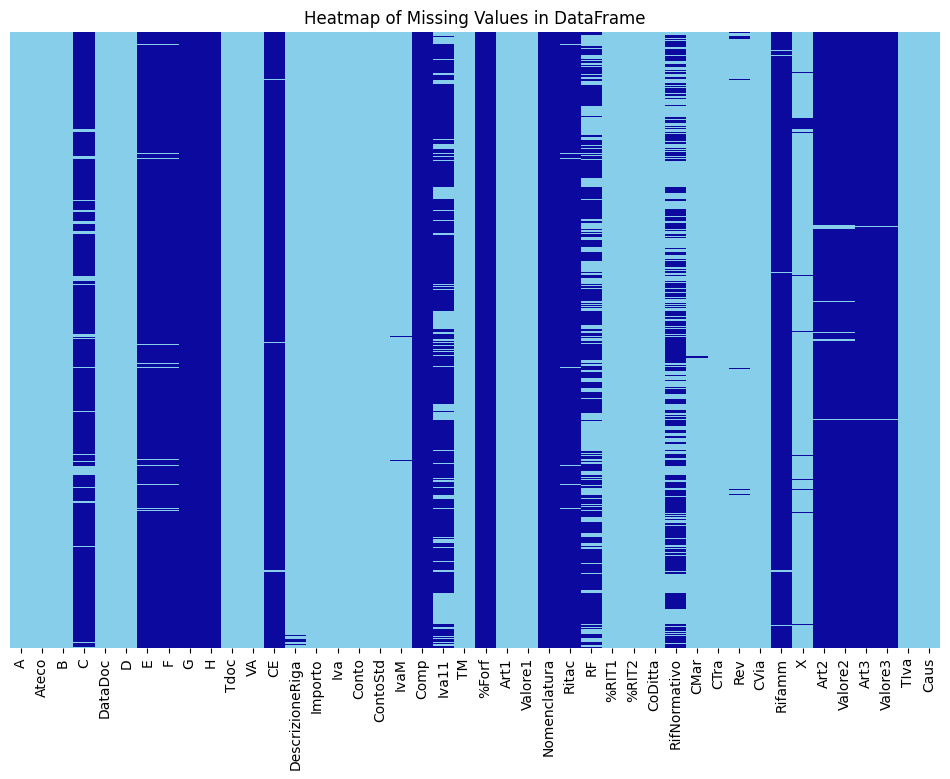

In [ ]:
plt.figure(figsize=(12, 8))
cmap = sns.color_palette(["skyblue", "#0C0A9E"])
sns.heatmap(null_data, cbar=False, yticklabels=False, cmap=cmap)
plt.title('Heatmap of Missing Values in DataFrame')
plt.show()

We can see several missing values.
As explained in the readme file, we have decided to remove the columns with the majority of missing entries as well as some others we considered not relevant for our classification.
The columns were remnoved in the section called 'Handle missing value' and the explanation can be found in the report.

Let's now explore values in the IvaM columns, our target variable.

In [ ]:
data['IvaM'].unique()

array([374., 315., 302.,  22., 314., 323., 354., 307., 326., 346., 310.,
       300., 324., 341., 375., 381.,  nan, 327., 312., 306., 325., 347.,
       308., 339., 309., 301., 318., 377., 372., 336.,  10.,   2., 622.,
       376.,  35., 371., 321., 369., 304., 317., 340., 322., 350., 345.,
        23., 316., 222., 399., 370., 311., 379., 110., 329., 303., 722.,
       367., 358., 334., 355., 331., 356.])

 We can see some unmapped values and a 'nan' string, which we assume to be a null value, that we will handle in the next section

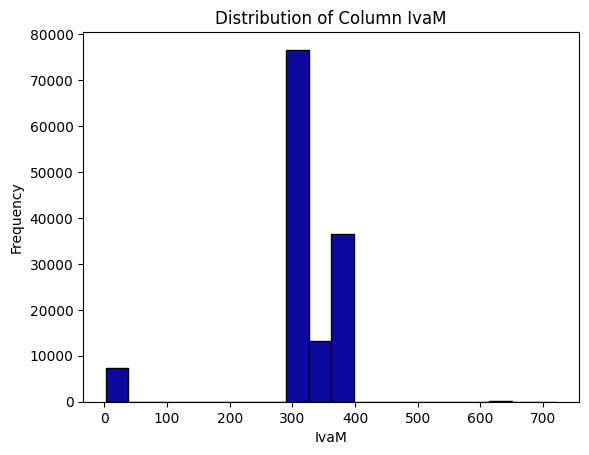

In [ ]:
plt.hist(data['IvaM'], bins=20, color='#0C0A9E', edgecolor='black')
plt.xlabel('IvaM')
plt.ylabel('Frequency')
plt.title('Distribution of Column IvaM')
plt.show()

We then obtained the value count of each class in the target variable, and plotted the value counts of each class below. Quite clearly the classes are unevenly distributed and imbalanced.

In [ ]:
data['IvaM'].value_counts()

IvaM
374.0    22129
324.0    20895
315.0    16589
312.0    11872
381.0    11061
22.0      7237
302.0     6522
310.0     6160
341.0     4426
326.0     4124
300.0     3771
325.0     3410
308.0     2628
317.0     2572
354.0     1960
377.0     1531
358.0     1104
375.0      844
340.0      626
314.0      616
307.0      576
371.0      544
336.0      439
306.0      425
346.0      365
370.0      230
372.0      192
309.0      189
10.0       175
304.0      152
323.0      144
622.0      106
345.0       68
347.0       67
301.0       65
376.0       29
356.0       23
322.0       20
318.0       11
379.0       11
2.0          8
327.0        5
311.0        5
35.0         5
222.0        4
329.0        3
399.0        3
331.0        3
321.0        3
303.0        3
722.0        3
334.0        2
350.0        2
316.0        2
367.0        2
355.0        1
23.0         1
110.0        1
339.0        1
369.0        1
Name: count, dtype: int64

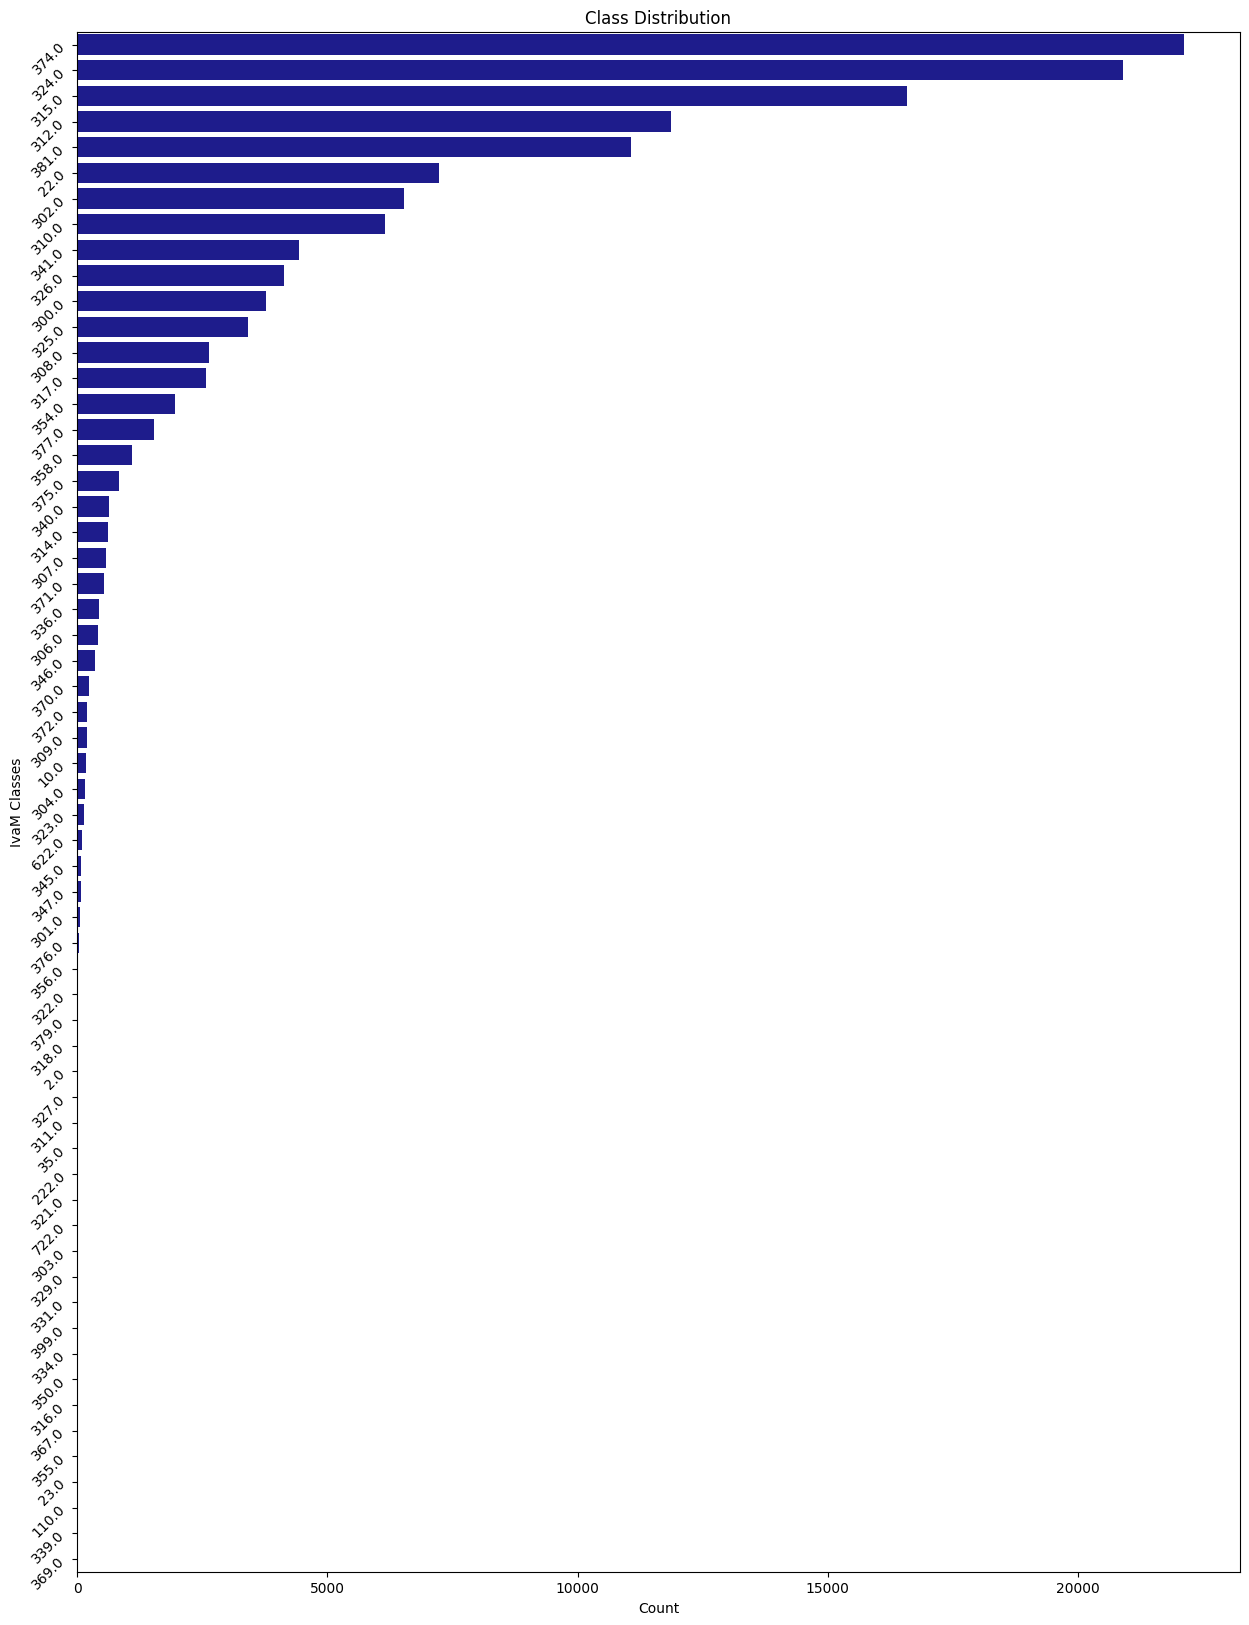

In [ ]:
class_counts = data['IvaM'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(15, 20))
sns.countplot(y='IvaM', data=data, order=class_counts.index, color="#0C0A9E")
plt.title('Class Distribution')
plt.xlabel('Count')
plt.ylabel('IvaM Classes')
plt.yticks(rotation=45, ha='right')
plt.show()

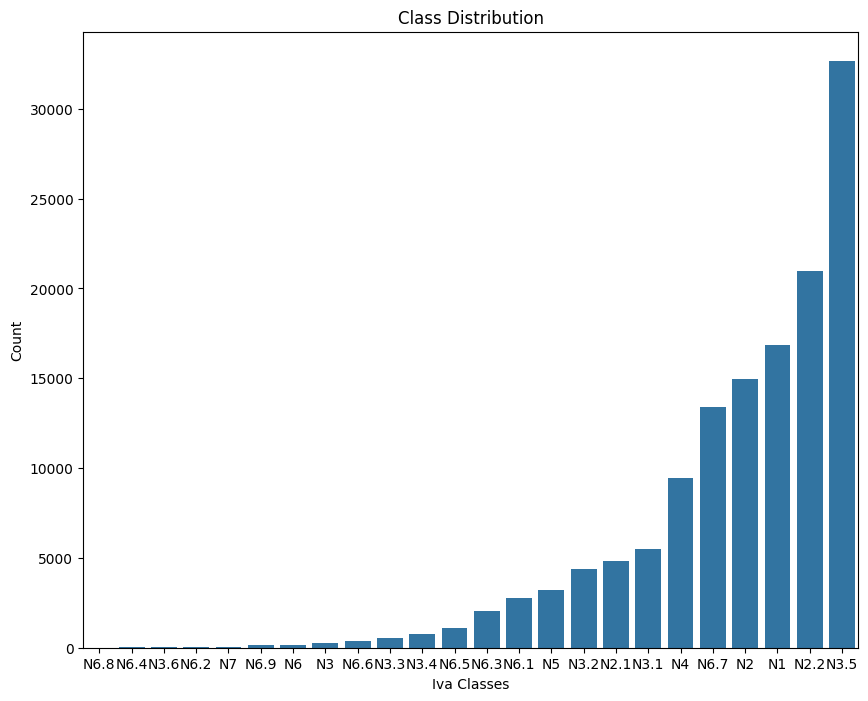

In [ ]:
class_counts = data['Iva'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 8))
sns.countplot(x='Iva', data=data, order=class_counts.index)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.xlabel('Iva Classes')
plt.show()

In the next section, we will deal with these issues and explore the unique values of each column we decided to keep.

# Data Cleaning and Preprocessing

## Handle missing values

We dropped the columns that are majorly comprised of missing values and those that contain unnecessary information, replaced the 'nan' string with a true NAN value, and finally dropped all invoices that contained an NAN value

In [5]:
drop_col = ['C', 'E', 'F', 'G', 'H', 'CE', 'Comp', 'Iva11', '%Forf', 'Nomenclatura', 'Ritac', 'RF',
            'RifNormativo', 'Rifamm', 'Art2', 'Valore2','Art3', 'Valore3', 'Conto', 'DataDoc', 'Rev',
            'X', 'CTra', 'CVia', '%RIT1', '%RIT2', 'CoDitta', 'CMar', 'Art1', 'Valore1', 'Caus', 'Importo', 'D', 'DescrizioneRiga']
data = data.drop(drop_col, axis=1)

In [6]:
data['IvaM'] = data['IvaM'].replace('nan', pd.NA)

In [7]:
data = data.dropna()

Below is the cleaned dataset, with 0 null values

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 133912 entries, 1 to 234501
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   A         133912 non-null  object 
 1   Ateco     133912 non-null  int64  
 2   B         133912 non-null  object 
 3   Tdoc      133912 non-null  object 
 4   VA        133912 non-null  object 
 5   Iva       133912 non-null  object 
 6   ContoStd  133912 non-null  int64  
 7   IvaM      133912 non-null  float64
 8   TM        133912 non-null  int64  
 9   TIva      133912 non-null  int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 11.2+ MB


## handle unmapped values

Of the remaining columns, we handled the unmapped values (values that were not present in the dataset description) by first obtaining a value count of the total numnber of unmapped values for each column. If the value count was small, we decided to drop them from the dataset to ensure that the dataset used to train the following models is consistent with the descriptions given. If the value count was large, we decided to manually map the unmapped values, as performed on the Iva column for values N2 and N3.

Although this may have introduced some bias, it was necesarry to ensure consistency with the documentation and the data, and avoids simply deleting the rows that contain N2 and N3.

Variable A contains 96 unmapped values to be dropped.

In [9]:
mapped_A = [1, 2, 3, 4, 5, 6, 7, 'E', 'O', 'S', 'N', 'M', 'F', 'G'] # list of values in A as per dataset description
unmapped_count = 0
for value in data['A']:
  if value not in mapped_A:
    unmapped_count += 1
print(unmapped_count)

data = data.drop(data[data['A'] == 'A'].index) # the character A was the unmapped value present in the A column, so it is dropped

96


Variable B contains 943 unmapped values to be dropped

In [10]:
mapped_B = ['S', 'C', 'X', 'N'] # list of mapped values in B as per dataset description
unmapped_count = 0
for value in data['B']:
  if value not in mapped_B:
    unmapped_count += 1
print(unmapped_count)

data = data.drop(data[(data['B']==0)].index) # the integer 0 was the unmapped value present in the B column, so it is dropped

943


Variable Iva contains 15238 unmapped values, which is a relatively high count of unmapped instances (~11.5% of the rows in the dataset). This was an issue since Iva column is strongly related to IvaM, as written in the Dataset Description


In [11]:
mapped_Iva = ['N2.2', 'N1', 'N6.7', 'N3.4', 'N3.1', 'N3.2', 'N3.6', 'N4', 'N6.3', 'N3.5', 'N6.1',
              'N6.9', 'N6.6', 'N2.1', 'N6.2', 'N5', 'N6', 'N6.8', 'N6.4', 'N3.3', 'N6.5', 'N7']     # list of mapped
unmapped_count = 0
for value in data['Iva']:
    if value not in mapped_Iva:
        unmapped_count += 1
print(unmapped_count)

15238


Iva Column: manually map values N3. Change N3 to proper Iva value (N3.1, N3.2, N3.3, N3.4, N3.5, N3.6, N3.7, N3.8, or N3.9), and change N2 to the proper Iva value (N2.1 or N2.2)

To perform manual mapping, we identified the unmapped values N2 and N3, as well as all of the corresponding IvaM values. Then, we returned a value count of the total number of rows that contained a mapped value (N2.1, N2.2 for example) and an IvaM value. We mapped N2 and N3 based on frequency of corresponding IvaM values.

For example, invoices containing unmapped Iva value N3 and IvaM value 314 were mapped to Iva value N3.4, because Iva value N3.4 is the Iva value with the highest frequency of being paired with IvaM value 314. We followed this logic to map all N2 and N3 values.  

In [12]:
 # map N3 to N3.4 if IvaM == 314 is the logic of this line. the same principle is carrier throughout this cell and the following cell
data['Iva'] = [val if val != 'N3' or data.loc[i, 'IvaM'] != 314 else 'N3.4' for i, val in data['Iva'].items()]
data['Iva'] = [val if val != 'N3' or data.loc[i, 'IvaM'] != 325 else 'N3.1' for i, val in data['Iva'].items()]
data['Iva'] = [val if val != 'N3' or data.loc[i, 'IvaM'] != 341 else 'N3.2' for i, val in data['Iva'].items()]
data['Iva'] = [val if val != 'N3' or data.loc[i, 'IvaM'] != 312 else 'N3.5' for i, val in data['Iva'].items()]
data['Iva'] = [val if val != 'N3' or data.loc[i, 'IvaM'] != 300 else 'N3.6' for i, val in data['Iva'].items()]

In [13]:
data['Iva'] = [val if val != 'N2' or data.loc[i, 'IvaM'] != 374 else 'N2.2' for i, val in data['Iva'].items()]
data['Iva'] = [val if val != 'N2' or data.loc[i, 'IvaM'] != 300 else 'N2.2' for i, val in data['Iva'].items()]
data['Iva'] = [val if val != 'N2' or data.loc[i, 'IvaM'] != 326 else 'N2.2' for i, val in data['Iva'].items()]
data['Iva'] = [val if val != 'N2' or data.loc[i, 'IvaM'] != 302 else 'N2.2' for i, val in data['Iva'].items()]
data['Iva'] = [val if val != 'N2' or data.loc[i, 'IvaM'] != 304 else 'N2.2' for i, val in data['Iva'].items()]
data['Iva'] = [val if val != 'N2' or data.loc[i, 'IvaM'] != 306 else 'N2.1' for i, val in data['Iva'].items()]
data['Iva'] = [val if val != 'N2' or data.loc[i, 'IvaM'] != 307 else 'N2.1' for i, val in data['Iva'].items()]
data['Iva'] = [val if val != 'N2' or data.loc[i, 'IvaM'] != 354 else 'N2.2' for i, val in data['Iva'].items()]
data['Iva'] = [val if val != 'N2' or data.loc[i, 'IvaM'] != 315 else 'N2.2' for i, val in data['Iva'].items()]

# there were no rows in the dataset that contained either N2.1 or N2.2 that also had 346 in the IvaM column, so we chose to delete these rows because we could not manually map
data = data.drop(data[(data['Iva']=='N2') & (data['IvaM']==346)].index)

## handle imbalanced classes in IvaM

To handle class being imbalanced, we have experimented several techniques, further explained in the read me file.

Our final choice was to first remove classes with less than 10 values, then create a second dataset that combines classes with less than 600 values, classes replaced with arbitrary **value 99** (transformed to the same data type as the other values) and
 by manually make list of the classes that have **less than 600 values**.

 This way we could reduce the dataset imbalance. However, on our best performing models, we have tested both on the balance and imbalanced datasets.

In [14]:
data = data[data['IvaM'].isin(data['IvaM'].value_counts()[lambda x: x >= 10].index)]

In [15]:
data_600 = data.copy()

group = [307, 371, 336, 306, 346, 370, 372, 309, 304, 323, 345, 347, 301, 376, 356, 322, 318, 379, 10, 622] # list of classes with less than 600 instances
replacement_value = 99

data_600['IvaM'] = data_600['IvaM'].astype(float)
data_600['IvaM'] = data_600['IvaM'].replace(to_replace=group, value=replacement_value)

## Encoding Categorical Variables

Again, as explained in the readme file we have tested several methods to encode, such as target encoding, but we have decided to perform one hot encoding.

We have decided to show the other option we tested to further show why we have excluded them.

In [16]:
# Convert all integer columns to strings except IvaM

data = data.apply(lambda x: x.astype(str) if x.name != 'IvaM' else x)
data_600 = data_600.apply(lambda x: x.astype(str) if x.name != 'IvaM' else x)

In [17]:
# Reset index to avoid duplicates

data = data.reset_index(drop=True)
data_600 = data_600.reset_index(drop=True)

To avoid editing the original dataset, we have created a copy to perform the encoding

In [18]:
data1 = data.copy()
data6001 = data_600.copy()

The onehot() function performs one hot encoding on categorical variables A, B, Tdoc, Iva, TM, and VA. These variables were extracted from the dataset and encoded, then appended to the other columns not encoded. The output of this function is the encoded dataset in addition to the columns not encoded (Ateco, ContoStd, TIva, IvaM)

In [19]:
def onehot(data):
  columns_to_encode = ['A', 'B', 'Tdoc', 'Iva', 'TM', 'VA'] # columns to encode
  data_to_encode = data[columns_to_encode]

  onehot_encoder = OneHotEncoder()
  encoded_data = onehot_encoder.fit_transform(data_to_encode)

  feature_names = onehot_encoder.get_feature_names_out(columns_to_encode)  # feature names of each encoded column
  encoded_df = pd.DataFrame(encoded_data.toarray(), columns=feature_names) # make into a pandas dataframe
  datatrain_encoded = pd.concat([data.drop(columns=columns_to_encode), encoded_df], axis=1) # concatenate the unencoded variables to encoded variables

  return datatrain_encoded

### Encoding Trials
the following functions onehot1() and onehot_target() are two trials of encoding that we decided not to use, but chose to still include to show our trials and thought process

Trial 1

**onehot1()** is a function that one hot encodes all categorical variables, excluding the target variable. This function was not included due to the "curse of dimensionality", as it increases the size of the dataset greatly, given that Ateco and ContoStd each have over 300 unique categories. This leads to a sparse dataset and an increased likelihood of overfitting, if applied to the models below.

In [20]:
def onehot1(data):
  columns_to_encode = ['A', 'B', 'Tdoc', 'Iva', 'TM', 'VA', 'Ateco', 'ContoStd', 'TIva'] # columns to encode
  data_to_encode = data[columns_to_encode]

  onehot_encoder = OneHotEncoder()
  encoded_data = onehot_encoder.fit_transform(data_to_encode)

  feature_names = onehot_encoder.get_feature_names_out(columns_to_encode) # extract feature names of each encoded column
  encoded_df = pd.DataFrame(encoded_data.toarray(), columns=feature_names) # make into pandas df
  datatrain_encoded = pd.concat([data.drop(columns=columns_to_encode), encoded_df], axis=1) # concatenate encoded variables to the unencoded target variable

  return datatrain_encoded

Trial 2

**onehot_target()** is a function that encodes variables with few unique classes (A, B, Tdoc, Iva, TM, TIva, VA) using one hot encoding, and encodes variable with a greater number of unique classes (Ateco, ContoStd) using target encoding.

This encoding method was not chosen because target encoding is sensitive to overfitting. After applying this method to the cleaned dataset and using the encoded dataset to train the models below, we saw the classifications were corresponding to the target encoded variables (ContoStd and Ateco) too closely, indicating overfitting due to these encoded variables. Thus, this method of encoding was not utilized.

In [21]:
def onehot_target(data):
  ohe_cols = ['A', 'B', 'Tdoc', 'Iva', 'TM', 'TIva', 'VA'] # variables for ohe
  target_cols = ['Ateco', 'ContoStd'] # variables for target encoding

  # One-hot encoding for specified features
  ohe_encoder = OneHotEncoder()
  ohe_encoded_df = ohe_encoder.fit_transform(data[ohe_cols]) # ohe
  ohe_encoded_df_columns = ohe_encoder.get_feature_names_out(ohe_cols)
  ohe_encoded_df = pd.DataFrame(ohe_encoded_df.toarray(), columns=ohe_encoded_df_columns)

  # Target encoding for specified features
  target_encoder = TargetEncoder()
  target_encoded_df =  data[target_cols].copy() # extract columns for target encoding and place in new variable "target_encoded_df"
  target_encoded_df = pd.DataFrame(target_encoder.fit_transform(target_encoded_df, data['IvaM'])) # target encoding and updating variable as a pandas df
  target_encoded_df.columns = target_cols

  # Combine encoded features with original features that don't require encoding
  all_encoded_df = pd.concat([data.drop(ohe_cols + target_cols, axis=1), ohe_encoded_df, target_encoded_df], axis=1)

  return all_encoded_df

Finally, apply the selected encoding (**onehot()**) on both datasets

In [22]:
data_encoded = onehot(data1)
data_600_encoded = onehot(data6001)

# Model Application and Selection

We have tested 7 models in total (KNN; Gradient Boost; Artificial Neural Network; Support Vector Machine; Decision Tree; Distributed Random Forest with H2O; Random Forest Classifier with Scikit Learn), and chose **KNN as our baseline**.


Based on the suggestion of TA Davide Torre, and results, we have decided to exclude the support vector machine, gradient boost and artificial neural network and proceed with more appropriate models.

In addition we have excluded logistic regression (which was not tested).

Our preferred model was random forest with scikit learn.

More detailed information will be found in the read me file.

For each model, a copy of the dataset was created.

## First Model: K Nearest Neighbor Classifier

The K-Nearest Neighbor (KNN) Classifier is a supervised learning model that finds k (a number) neighbors to a given data point based on some distance metric. It is necessary to determine the optimal k value that will produce a trained model that most accurately classifies the target variable. We first determined the optimal k value (5), and then performed a grid search to determine the hyperparameter values to utilize, including the distance measurement metric and weights of each datapoint.

After finetuning the hyperparameters:

**accuracy of model trained on imbalanced dataset**: 0.9618

**accuracy of model trained on balanced dataset**: 0.9624

**accuracy of model trained on balanced dataset, class 99**: 0.9064


In [ ]:
#make a copy of the datasets

knn_1 = data_encoded.copy()
knn_600 = data_600_encoded.copy()

### Functions for obtaining KNN metrics, precision-recall curve plot
The following functions were applied to both KNN models.

**knn_metrics** takes the y_test variable and y_pred variable after training the knn models as input, and computes the accuracy, precision, recall, f1 score, overall classification report, and confusion matrix of the trained model.

**knn_pr** takes the y_test variable and y_pred variable after training the knn models as input, and outputs a visualization of the precision-recall curve for each class in the target variable.

In [ ]:
def knn_metrics(ytest, ypred):

  # accuracy
  accuracy = accuracy_score(ytest, ypred)
  print("Accuracy:", accuracy)

  # Precision
  precision = precision_score(ytest, ypred, average='weighted')
  print("Precision:", precision)

  # Recall
  recall = recall_score(ytest, ypred, average='weighted')
  print("Recall:", recall)

  # F1 Score
  f1 = f1_score(ytest, ypred, average='weighted')
  print("F1 Score:", f1)

  # Classification Report
  print("Classification Report:")
  print(classification_report(ytest, ypred))

  # Confusion Matrix
  print("Confusion Matrix:")
  print(confusion_matrix(ytest, ypred))

In [ ]:
def knn_pr(ytest, ypred):
  classes = np.unique(ytest)

  precision_dict = dict()
  recall_dict = dict()

  # calculate precision and recall for each class
  for i in range(len(classes)):
    precision_dict[i], recall_dict[i], _ = precision_recall_curve((ytest == classes[i]).astype(int), (ypred == classes[i]).astype(int))

  # plot the curve for each class
  plt.figure(figsize=(10, 8))
  for i in range(len(classes)):
    plt.plot(precision_dict[i], recall_dict[i], marker='.', label=f'Class {classes[i]}')

  plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
  plt.xlabel('Precision')
  plt.ylabel('Recall')
  plt.title('Precision-Recall Curve for each class')
  plt.gca().invert_yaxis()
  plt.show()

### Imbalanced dataset

the values of X (feature variables) are defined as all variables excluding IvaM

the value of y (target variable) is IvaM

the data frame was split into train and test datasets, 80% and 20% respectively.

In [ ]:
X = knn_1.drop(columns=['IvaM'])
y = knn_1['IvaM']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

To find the ideal k value, we performed the KNN classifier on the imbalanced dataset for a range of k values from 1 to 30, then plotted the accuracy of the model for each value of k.

After k=5, the accuracy of the model decreases consistently.

At k=1, the accuracy of the model is very high, but because the given datapoint is simply assigned to its nearest neighbor, without considering other neighbors. This high accuracy is indicative of overfitting.

Therefore, we chose the range from k=2 to k=5 when performing grid search.

In [ ]:
accuracy = [] # list to store accuracy values of each model

for k in range(1, 30):
  knn = KNeighborsClassifier(n_neighbors=k) # knn classifier for each value of k, 1 to 30
  knn.fit(X_train, y_train)
  y_pred = knn.predict(X_test)
  accuracy.append(accuracy_score(y_test, y_pred)) # obtain accuracy score

# plot accuracy vs k
plt.figure(figsize=(10,6))
plt.plot(range(1,30),accuracy,color = 'blue',linestyle='dashed',
         marker='o',markerfacecolor='red', markersize=10)
plt.title('accuracy vs. K Value')
plt.xlabel('K')
plt.ylabel('Accuracy')
print("Maximum accuracy:-",max(accuracy),"at K =",accuracy.index(max(accuracy)))

KeyboardInterrupt: 

We then performed grid search to find the optimal combination of hyperparameters that results in a knn model with the highest accuracy.

The hyperparameters we fine-tuneded are:

**n_neighbors** k = 2 to k = 5

**weights** uniform weights or weights based on distance, where closer neighbors have greater influence on a given data point than farther neighbors

**metric** metric used for the distance calculation, minkowski or euclidean


the ideal hyperparameters are **n_neighbors=5, metric=minkowski, weights=distance**

In [ ]:
grid_params = { 'n_neighbors' : [2, 3, 4, 5], 'weights' : ['uniform','distance'], 'metric' : ['minkowski','euclidean']}
gs = GridSearchCV(estimator=KNeighborsClassifier(), param_grid = grid_params, verbose = 1, cv=5, scoring='accuracy')
gs.fit(X_train, y_train)

print(gs.best_params_)
print(gs.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
{'metric': 'minkowski', 'n_neighbors': 5, 'weights': 'distance'}
0.9600944746129592


Now training the KNN model with the determined parameters, we obtain an **accuracy score of 0.9618**. This is our baseline accuracy score to compare to all further models trained imbalanced dataset.

The precision, recall, F1, full classification report of the scores of each individual class, and confusion matrix are returned below.

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', weights='distance')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [ ]:
# obtain knn metrics
knn_metrics(y_test, y_pred)

Accuracy: 0.9618266009110417
Precision: 0.9617477573891987
Recall: 0.9618266009110417


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


F1 Score: 0.9592550262515593
Classification Report:
              precision    recall  f1-score   support

        10.0       0.63      0.63      0.63        38
        22.0       0.94      0.96      0.95      1435
       300.0       0.91      0.78      0.84       783
       301.0       0.83      0.67      0.74        15
       302.0       0.95      0.94      0.95      1286
       304.0       0.83      0.92      0.88        38
       306.0       0.97      0.98      0.97        90
       307.0       0.98      0.95      0.96       130
       308.0       0.94      0.97      0.96       530
       309.0       0.92      0.97      0.95        37
       310.0       0.92      0.96      0.94      1242
       312.0       0.98      0.97      0.97      2337
       314.0       0.98      0.97      0.98       129
       315.0       0.97      0.97      0.97      3301
       317.0       1.00      1.00      1.00       535
       318.0       0.00      0.00      0.00         2
       322.0       0.00      

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


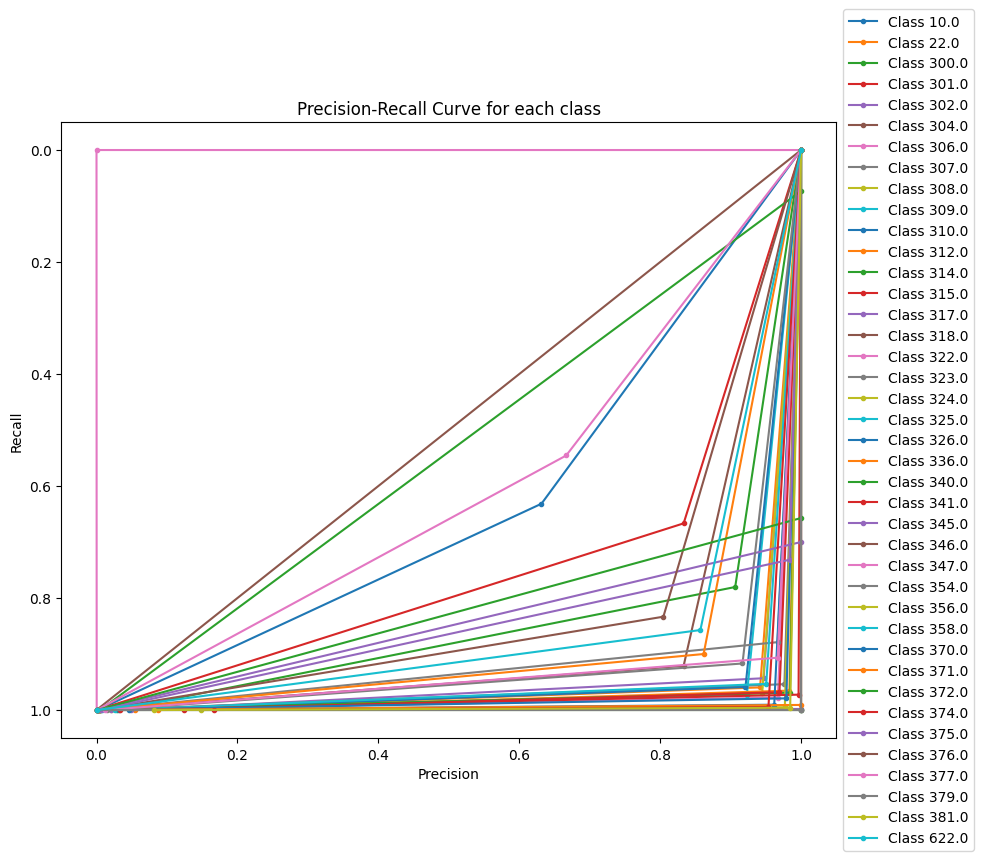

In [ ]:
knn_pr(y_test, y_pred)

### Balanced dataset

we trained a second knn classifier model on the balanced dataset using the same hyperparameter values as determined above.

we obtain an accuracy score of 0.9624. This is our baseline accuracy score to compare to all further models trained on the balanced dataset.

The precision, recall, F1, full classification report of the scores of each individual class, confusion matrix, and precision recall curve are returned below.

In [ ]:
X = knn_600.drop(columns=['IvaM'])
y = knn_600['IvaM']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', weights='distance')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [ ]:
knn_metrics(y_test, y_pred)

Accuracy: 0.9624289425140232
Precision: 0.9625770234519593
Recall: 0.9624289425140232
F1 Score: 0.9600363251193558
Classification Report:
              precision    recall  f1-score   support

        22.0       0.94      0.96      0.95      1435
        99.0       0.93      0.91      0.92       812
       300.0       0.91      0.78      0.84       783
       302.0       0.95      0.94      0.95      1286
       308.0       0.94      0.97      0.96       530
       310.0       0.92      0.96      0.94      1242
       312.0       0.98      0.97      0.97      2337
       314.0       0.98      0.97      0.98       129
       315.0       0.97      0.97      0.97      3301
       317.0       1.00      1.00      1.00       535
       324.0       0.98      0.99      0.98      3940
       325.0       0.95      0.95      0.95       686
       326.0       0.96      0.99      0.98       842
       340.0       1.00      0.07      0.14       137
       341.0       1.00      0.97      0.98       8

By aggregating the classes with values lower than 600 into class 99, we observe more classes with higher precision and recall.

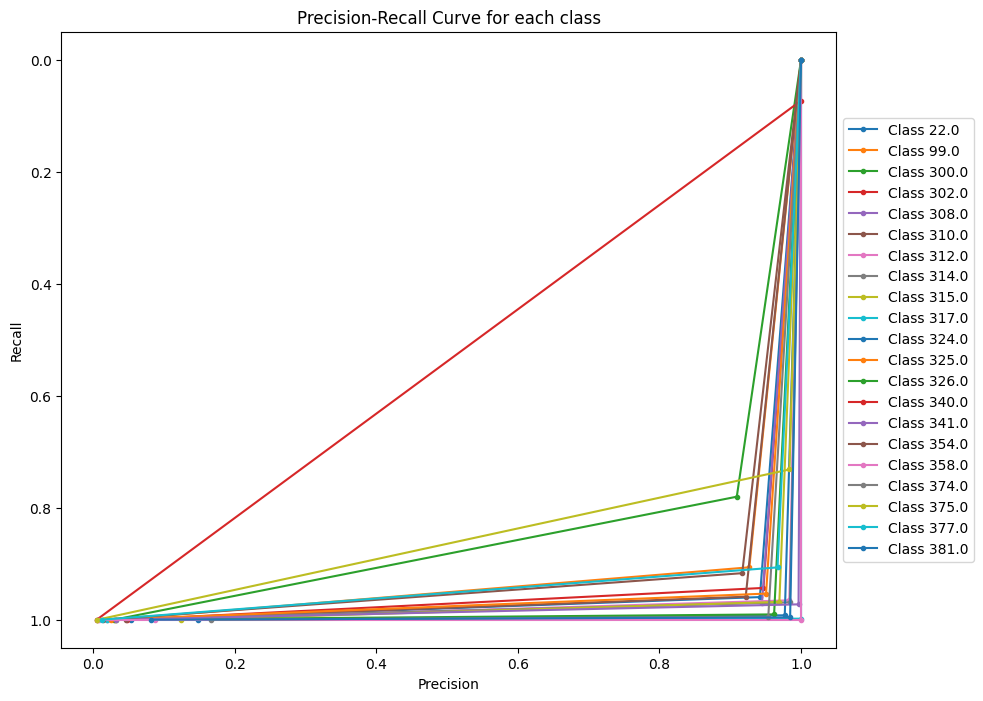

In [ ]:
knn_pr(y_test, y_pred)

We also include the KNN model's capability of classifying the classes in class 99 (classes with less than 600 values). We filtered the test dataset for class 99, then computed the metrics, most notably the accuracy score.

**Accuracy score**: 0.9064

In [ ]:
replacement_value = (y_test == 99.0)

y_pred_class_99 = y_pred[replacement_value]
y_true_class_99 = y_test[replacement_value]

knn_metrics(y_true_class_99, y_pred_class_99)

Accuracy: 0.9064039408866995
Precision: 1.0
Recall: 0.9064039408866995
F1 Score: 0.9509043927648578
Classification Report:
              precision    recall  f1-score   support

        22.0       0.00      0.00      0.00         0
        99.0       1.00      0.91      0.95       812
       300.0       0.00      0.00      0.00         0
       302.0       0.00      0.00      0.00         0
       310.0       0.00      0.00      0.00         0
       312.0       0.00      0.00      0.00         0
       314.0       0.00      0.00      0.00         0
       315.0       0.00      0.00      0.00         0
       324.0       0.00      0.00      0.00         0
       325.0       0.00      0.00      0.00         0
       326.0       0.00      0.00      0.00         0
       354.0       0.00      0.00      0.00         0
       374.0       0.00      0.00      0.00         0
       377.0       0.00      0.00      0.00         0
       381.0       0.00      0.00      0.00         0

    accurac

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarni

## Second Model: Support Vector Machine

The SVM model aims to find the optimal hyperplane that maximizes the margin between different classes in the feature space. SVM works by finding the hyperplane that best divides a dataset into classes with the largest margin between the nearest data points of any class (support vectors). We decided to exclude it as it was too slow to train and evaluate, and also returned a significantly lower accuracy score.

**Accuracy of model trained on imbalanced dataset**: 0.4441

In [ ]:
svm_df = data_encoded.copy()
svm_df_600 = data_600_encoded.copy()

For our first trial with SVM, performed SVM with standard scaler applied.

In [ ]:
X = svm_df.drop('IvaM', axis=1)
y = svm_df['IvaM']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# attempt with standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

# metrics
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)

         Ateco ContoStd  A_1  A_2  A_3  A_4  A_5  A_6  A_7  A_E  ...  TM_16  \
0       476220  6625005  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  ...    0.0   
1       476220  6625005  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  ...    0.0   
2       476220  6625005  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  ...    0.0   
3       476220  6625005  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  ...    0.0   
4       476220  6625005  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  ...    0.0   
...        ...      ...  ...  ...  ...  ...  ...  ...  ...  ...  ...    ...   
132809  563000  1840005  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  ...    0.0   
132810  563000  1840005  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  ...    0.0   
132811  563000  1840005  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  ...    0.0   
132812  563000  1840005  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  ...    0.0   
132813  563000  1840005  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  ...    0.0   

        TM_18  TM_19  TM_20  TM_3  TM_4  TM_7  TM_8

However, it did not make sense to perform standard scaler on the categorical variables. Therefore, below is the implementation of a function taht performs SVM. This was applied to both the balanced and imbalanced datasets. The following function **implement_svm()** trains the SVM model on the input data, and returns metric scores (accuracy, precision, recall, f1, full classification report, and confusion matrix)

In [ ]:
def implement_svm(data):

    X = svm_df.drop('IvaM', axis=1)
    y = svm_df['IvaM']


    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Training the SVM model with RBF since it handles complex decision boundaries
    svm_model = SVC(kernel='rbf', random_state=42)
    svm_model.fit(X_train, y_train)
    y_pred = svm_model.predict(X_test)

    # Evaluating the model
    # accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy:", accuracy)

    # Precision
    precision = precision_score(y_test, y_pred, average='weighted')
    print("Precision:", precision)

    # Recall
    recall = recall_score(y_test, y_pred, average='weighted')
    print("Recall:", recall)

    # F1 Score
    f1 = f1_score(y_test, y_pred, average='weighted')
    print("F1 Score:", f1)

    # Classification Report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


### imbalanced dataset

In [ ]:
implement_svm(svm_df)

Accuracy: 0.44411399314836425
Precision: 0.3698383465218394
Recall: 0.44411399314836425
F1 Score: 0.37680798140685695
Classification Report:
              precision    recall  f1-score   support

        10.0       0.00      0.00      0.00        38
        22.0       0.17      0.00      0.00      1435
       300.0       0.36      0.02      0.04       783
       301.0       0.00      0.00      0.00        15
       302.0       0.58      0.86      0.69      1286
       304.0       0.00      0.00      0.00        38
       306.0       0.00      0.00      0.00        90
       307.0       0.00      0.00      0.00       130
       308.0       0.00      0.00      0.00       530
       309.0       0.00      0.00      0.00        37
       310.0       0.30      0.53      0.38      1242
       312.0       0.47      0.39      0.43      2337
       314.0       0.00      0.00      0.00       129
       315.0       0.48      0.40      0.44      3301
       317.0       0.00      0.00      0.00     

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:13

## Third Model: Gradient Boost Machine

GBM builds a strong predictive model by combining multiple weak models, such as decision trees, by iteratively adding trees, each correcting errors from previous trees using gradient descent on the loss function.iteratively correcting errors to enhance performance. Here below is our GBM Model creation.

**accuracy of model trained on imbalanced dataset:** 0.9001

In [ ]:
xgb_df = data_encoded.copy()

In [ ]:
def implement_gbm(data):

    X = xgb_df.drop('IvaM', axis=1)
    y = xgb_df['IvaM']

    # Splitting the df
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Training the GBM model
    gbm_model = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=3, random_state=42)
    gbm_model.fit(X_train, y_train)

    # Predicting
    y_pred = gbm_model.predict(X_test)

    # Evaluating the model
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    print(f"Accuracy: {accuracy}")
    print("Classification Report:")
    print(report)

implement_gbm(data_encoded)

Accuracy: 0.900124232955615
Classification Report:
              precision    recall  f1-score   support

        10.0       1.00      0.08      0.15        38
        22.0       0.91      0.92      0.91      1435
       300.0       0.73      0.69      0.71       783
       301.0       0.13      0.40      0.20        15
       302.0       0.94      0.90      0.92      1286
       304.0       0.51      0.76      0.61        38
       306.0       0.00      0.03      0.01        90
       307.0       0.81      0.27      0.40       130
       308.0       0.91      0.95      0.93       530
       309.0       0.96      0.68      0.79        37
       310.0       0.90      0.89      0.90      1242
       312.0       0.99      0.96      0.97      2337
       314.0       0.00      0.00      0.00       129
       315.0       0.97      0.98      0.97      3301
       317.0       1.00      0.99      1.00       535
       318.0       0.00      0.00      0.00         2
       322.0       0.00      0

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## Fourth Model: Neural Network

Here, we have decided to take a look at a Neural Network model. ANN consists of multiple layers of interconnected neurons that process input data through nonlinear transformations. The model learns to map inputs to outputs by adjusting weights through backpropagation, learning patterns across data. We created this neural network model for classification using TensorFlow and Keras. We started by  preparing the input features and target labels, defining a sequential model architecture with dense layers. Then we applied a batch normalization and dropout for regularization, and compiled the model with categorical crossentropy loss and chose the Adam optimizer.


**Accuracy of model trained on balanced dataset**: 0.6458

In [23]:
# make copy of balanced dataset
DT600 = data_600_encoded.copy()

In [24]:
# Initiating the neural network
EPOCHS = 100
BATCH_SIZE = 128
VERBOSE = 1
NB_CLASSES = len(DT600['IvaM'].unique())
N_HIDDEN = 256
VALIDATION_SPLIT = 0.2


X = DT600.drop(columns=['IvaM'])
y = DT600['IvaM']

# let's encode the target variable to ensure they start from 0
y = y.astype('category').cat.codes

# train and text
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# we need to convert to NumPy arrays to make sure we have no problem in the NN
X_train = np.array(X_train).astype('float32')
X_test = np.array(X_test).astype('float32')

# stating our encoding
y_train = keras.utils.to_categorical(y_train, num_classes=NB_CLASSES)
y_test = keras.utils.to_categorical(y_test, num_classes=NB_CLASSES)


Here we define the neural network model with multiple hidden layers using the Keras Sequential API, incorporating batch normalization and dropout layers to prevent overfitting.

In [28]:
# let's define the model with the number of hidden layer desired
model = tf.keras.models.Sequential()
model.add(keras.layers.Dense(N_HIDDEN, input_shape=(X_train.shape[1],), activation='relu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(N_HIDDEN, activation='relu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(N_HIDDEN, activation='relu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(NB_CLASSES, activation='softmax'))

# we chose adam as optimizer
optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

#to adjust learning rate during training
lr_scheduler = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)

# stop if nor improvement training will stop if there is no improvement in the validation loss for 15 consecutive epochs.
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)


Here, we train our neural network and review the accuracy results to evaluate the performance of this model.

In [26]:
# train and evaluation
history = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=VALIDATION_SPLIT, verbose=VERBOSE, callbacks=[early_stopping, lr_scheduler])
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=VERBOSE)
print(f'Test accuracy: {test_acc}')

Epoch 1/100
582/582 [==============================] - 10s 14ms/step - loss: 2.0908 - accuracy: 0.4229 - val_loss: 1.9681 - val_accuracy: 0.3181 - lr: 0.0010
Epoch 2/100
582/582 [==============================] - 7s 12ms/step - loss: 1.7000 - accuracy: 0.4931 - val_loss: 1.5692 - val_accuracy: 0.5280 - lr: 0.0010
Epoch 3/100
582/582 [==============================] - 6s 11ms/step - loss: 1.6213 - accuracy: 0.5103 - val_loss: 1.6634 - val_accuracy: 0.4868 - lr: 0.0010
Epoch 4/100
582/582 [==============================] - 8s 14ms/step - loss: 1.5756 - accuracy: 0.5185 - val_loss: 1.4100 - val_accuracy: 0.5750 - lr: 0.0010
Epoch 5/100
582/582 [==============================] - 6s 10ms/step - loss: 1.5483 - accuracy: 0.5273 - val_loss: 1.3988 - val_accuracy: 0.5760 - lr: 0.0010
Epoch 6/100
582/582 [==============================] - 8s 13ms/step - loss: 1.5171 - accuracy: 0.5388 - val_loss: 1.3529 - val_accuracy: 0.5813 - lr: 0.0010
Epoch 7/100
582/582 [==============================] - 6s

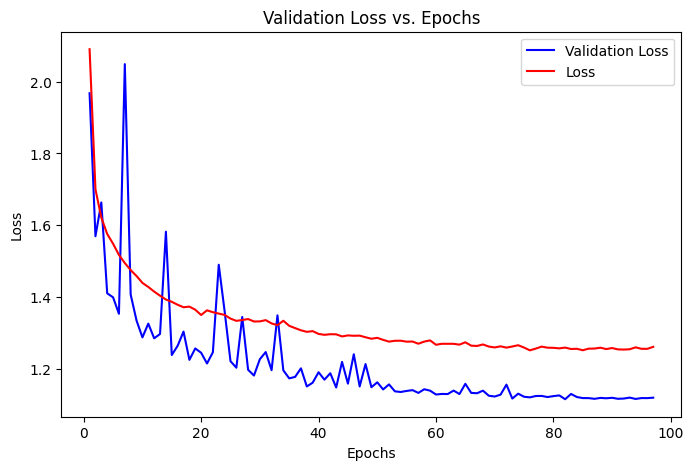

In [29]:
#Now we plot the data by checking the val loss and epochs
val_loss = history.history['val_loss']
loss = history.history['loss']
epochs = range(1, len(val_loss) + 1)


plt.figure(figsize=(8, 5))
plt.plot(epochs, val_loss, 'b-', label='Validation Loss')
plt.plot(epochs, loss, 'r-', label='Loss')
plt.title('Validation Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Reason for excluding SVM,XGB and NN

The model is computational expensive, which is something we want to avoid considering this classification wants to be applied in real world scenario, where the correct classification of IvaM should be fast.

## Fifth Model: Decision Tree

Decision tree is a supervised learning model that splits the input dataset into "branches" based on the features within the dataset. Each branch is a decision rule, and the leaves of the tree represent the final classification of the datapoint, based on the decisions made when considering the feature variables within the dataset.

Unlike random forest classifiers, decision trees are simply one tree. However, hyperparameter fine-tuning was still performed, to obtain the highest accuracy possible for this model.

**Accuracy of model trained on imbalanced dataset**: 0.9687

**Accuracy of model trained on balanced dataset**: 0.9698

**Accuracy of model trained on balanced dataset, class 99**: 0.9200

In [ ]:
# make a copy of the datasets

dtree = data_encoded.copy()
dtree_600 = data_600_encoded.copy()

### Function for obtaining decision tree metrics
The following function was applied to both decision tree models.

dtree_metrics takes the y_test variable and y_pred variable after training the knn models as input, and computes the accuracy, f1 score, overall classification report, and confusion matrix of the trained model.

In [ ]:
def dtree_metrics(ytest, ypred):
  # Accuracy
  accuracy = accuracy_score(ytest, ypred)
  print(f'Accuracy: {accuracy}')

  # Precision
  precision = precision_score(y_test, y_pred, average='weighted')
  print("Precision:", precision)

  # Recall
  recall = recall_score(y_test, y_pred, average='weighted')
  print("Recall:", recall)

  # F1 Score
  f1 = f1_score(ytest, ypred, average='weighted')
  print("F1 Score:", f1)

  # Confusion Matrix
  conf_matrix = confusion_matrix(ytest, ypred)
  print('Confusion Matrix:')
  print(conf_matrix)

  # Classification Report
  class_report = classification_report(ytest, ypred)
  print('Classification Report:')
  print(class_report)

### Imbalanced dataset

In [ ]:
X = dtree.drop(columns=['IvaM'])
y = dtree['IvaM']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

We performed grid search to determine the optimal combination of hyparameters, including max_depth, min_samples_split, and min_samples_leaf, based on accuracy score of each parameter combination.

**max_depth** is a value of how deep the decision tree is, with deeper trees having more splitting (more decisions made to classify) and captures more information of the input dataset.

**min_samples_split** is a value of the minimum number of data points required to split a node within the tree, where lower values indicate that the node will split further with few samples at each node and higher values indicate that the node will split further when more samples are at each node. Lower values of min_samples_split may be prone to the model overfitting the data, while too high values may be prone to simplfy the decision tree too much and the model underfitting the data.

**min_samples_leaf** is a value of the minimum number of datapoints required to be at a leaf node, the final classification node. Lower values allow for more speficic predictions but may lead to overfitting the data.



In [ ]:
grid_params = { 'max_depth' : [5, 10, 15, 20, 25, 30],
               'min_samples_split' : [2, 5, 10],
                'min_samples_leaf' : [1, 3, 5]}
gs = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid = grid_params, verbose = 1, cv=5, scoring='accuracy')
gs.fit(X_train, y_train)

print(gs.best_params_)
print(gs.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
{'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2}
0.9680002847755261


After determining the ideal hyperparamters (max_depth=30, min_samples_split=2, min_samples_leaf=1), the accuracy of the model is 0.9688

In [ ]:
clf = DecisionTreeClassifier(max_depth=30, min_samples_leaf=1, min_samples_split=2, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [ ]:
dtree_metrics(y_test, y_pred)

Accuracy: 0.9697699808003614
Precision: 0.9699532886817769
Recall: 0.9697699808003614
F1 Score: 0.9674576515853488
Confusion Matrix:
[[1411   21    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    3]
 [  19  747    2    0    0   11    7    3    2    1   11    3    1    0
     0    1    0    3    0    0    1]
 [   0    6  632   61    7   14    1    0   19    0    0    0   15    0
     0   15    0   10    0    3    0]
 [   0    4   22 1237    0    0    0    0    0    0    0    0   20    0
     0    1    0    2    0    0    0]
 [   0    0    0    0  512   17    0    0    1    0    0    0    0    0
     0    0    0    0    0    0    0]
 [   0   13    0    1   12 1214    0    0    1    0    0    1    0    0
     0    0    0    0    0    0    0]
 [   0    0    0    0    0    0 2257    0    0    0   78    2    0    0
     0    0    0    0    0    0    0]
 [   0    0    2    0    0    0    0  127    0    0    0    0    0    0
     0    0    0    0    

### Balanced dataset

A decision tree model was trained on the balanced dataset, with the determined hyperparameters

the accuracy of this model was also slightly higher than the imbalanced dataset, 0.9698

In [ ]:
X = dtree_600.drop(columns=['IvaM'])
y = dtree_600['IvaM']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
clf = DecisionTreeClassifier(max_depth=30, min_samples_leaf=1, min_samples_split=2, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [ ]:
dtree_metrics(y_test, y_pred)

Accuracy: 0.9697699808003614
Precision: 0.9699532886817769
Recall: 0.9697699808003614
F1 Score: 0.9674576515853488
Confusion Matrix:
[[1411   21    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    3]
 [  19  747    2    0    0   11    7    3    2    1   11    3    1    0
     0    1    0    3    0    0    1]
 [   0    6  632   61    7   14    1    0   19    0    0    0   15    0
     0   15    0   10    0    3    0]
 [   0    4   22 1237    0    0    0    0    0    0    0    0   20    0
     0    1    0    2    0    0    0]
 [   0    0    0    0  512   17    0    0    1    0    0    0    0    0
     0    0    0    0    0    0    0]
 [   0   13    0    1   12 1214    0    0    1    0    0    1    0    0
     0    0    0    0    0    0    0]
 [   0    0    0    0    0    0 2257    0    0    0   78    2    0    0
     0    0    0    0    0    0    0]
 [   0    0    2    0    0    0    0  127    0    0    0    0    0    0
     0    0    0    0    

We also include the decision tree model's capability of classifying the classes in class 99 (classes with less than 600 values). We filtered the test dataset for class 99, then computed the metrics, most notably the accuracy score.

In [ ]:
replacement_value = (y_test == 99.0)

y_pred_class_99 = y_pred[replacement_value]
y_true_class_99 = y_test[replacement_value]

dtree_metrics(y_true_class_99, y_pred_class_99)

Accuracy: 0.9199507389162561
Precision: 0.9699532886817769
Recall: 0.9697699808003614
F1 Score: 0.9583066067992302
Confusion Matrix:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 19 747   2  11   7   3   2   1  11   3   1   1   3   1]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0]]
Classification Report:
              pre

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## Sixth Model: Distributed Random Forest with H2O

H2O is a ML and predictive analytics platform to build ML models, including Distributed Random Forest Classifiers. Distributed Random Forest Classifier with H2O generates several decision tree classifications (a forest), and takes the average prediction across all trees to make a final prediction of classification.

This model was considered to be trained because of its ability to handle categorical variables without encoding them beforehand. Therefore, we utilized the unencoded dataset to train the models on the balanced and imbalanced datasets.

The metric to score the DRF model is log loss.

**Log loss of model trained on imbalanced dataset:** 0.1153

**Log loss of model trained on balanced dataset:** 0.1125

In [ ]:
# initialize h2o instance
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "11.0.22" 2024-01-16; OpenJDK Runtime Environment (build 11.0.22+7-post-Ubuntu-0ubuntu222.04.1); OpenJDK 64-Bit Server VM (build 11.0.22+7-post-Ubuntu-0ubuntu222.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.10/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpivwt5297
  JVM stdout: /tmp/tmpivwt5297/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpivwt5297/h2o_unknownUser_started_from_python.err


/usr/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _posixsubprocess.fork_exec(


  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,06 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.2
H2O_cluster_version_age:,6 days
H2O_cluster_name:,H2O_from_python_unknownUser_xjtlcr
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.170 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


### imbalanced dataset

In [ ]:
# transform data to an H2O frame
df = h2o.H2OFrame(data)

# enforce that target variable will be recognized as categorical
df['IvaM'] = df['IvaM'].asfactor()

X = ['A', 'B', 'Tdoc', 'VA', 'Iva', 'TM', 'TIva', 'Ateco', 'ContoStd']
y = 'IvaM'

train, test = df.split_frame(ratios=[.8], seed=42)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


We attempted to performed a grid search to determine the optimal combination of the following parameters to minimize the logloss and the root mean squared error (RMSE) of the model. However, we found that it was more effective and less time consuming to find the optimal combination of parameters manually.

In the case of Distributed Random Forest, H2O does not report the accuracy score of multiclass classification models, and therefore we chose to score the model based on the lowest logloss score. The model automatically outputs the metrics (Mean Squared Error, Root Mean Squared Error, Log Loss, Confusion Matrix, variable importance) for both the training and test data. The reported value is the log loss of the test set.

**ntrees** is the number of trees to build in the DRF model.

**max_depth** is similar to that of the decision tree, how deep the tree is, where deeper trees have better accuracy.

**min_rows** is the minimum number of observations for a node in order to split.

**nbins_cats** is specifically for categorical variables, as a method to control categorical feature binning to group similar categories together

**seed** is for reproducibility of results

The optimal parameters were determined to be ntrees=30, maxdepth=16, min_rows=2, and nbins_cats=1024.

In [ ]:
df_drf = H2ORandomForestEstimator(ntrees=30, max_depth=16, min_rows=2, nbins_cats=1024, seed=42)

df_drf.train(x=X, y=y, training_frame=train, validation_frame=test)

drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


Model Details
=============
H2ORandomForestEstimator : Distributed Random Forest
Model Key: DRF_model_python_1716187919807_1


Model Summary: 
    number_of_trees    number_of_internal_trees    model_size_in_bytes    min_depth    max_depth    mean_depth    min_leaves    max_leaves    mean_leaves
--  -----------------  --------------------------  ---------------------  -----------  -----------  ------------  ------------  ------------  -------------
    30                 1200                        1.2056e+06             1            16           11.695        2             474           75.5492

ModelMetricsMultinomial: drf
** Reported on train data. **

MSE: 0.03303693878289662
RMSE: 0.1817606634640637
LogLoss: 0.1391787158346054
Mean Per-Class Error: 0.18374148866364357
AUC table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).
AUCPR table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).

Confusion Matrix: Row labels: Actual class; Column labels: Predicted class
10    22      300     301    302     304    306    307    308     309    310     312     314    315      317     318    322    323    324      325     326     336    340    341     345    346    347    354     356    358    370    371    372    374      375    376    377     379    381     622    Error                  Rate
----  ------  ------  -----  ------  -----  -----  -----  ------  -----  ------  ------  -----  -------  ------  -----  -----  -----  -------  ------  ------  -----  -----  ------  -----  -----  -----  ------  -----  -----  -----  -----  -----  -------  -----  -----  ------  -----  ------  -----  ---------------------  ---------------
23.0  116.0   0.0     0.0    0.0     0.0    0.0    0.0    0.0     0.0    0.0     0.0     0.0    0.0      0.0     0.0    0.0    0.0    0.0      0.0     0.0     0.0    0.0    0.0     0.0    0.0    0.0    0.0     0.0    0.0    0.0    0.0    0.0    0.0      0.0    0.0    0.0     0.0    0.0     0.0    0.8345323741007195     116 / 139
2.0   5604.0  4.0     0.0    0.0     0.0    0.0    0.0    0.0     0.0    1.0     0.0     0.0    0.0      0.0     0.0    0.0    0.0    0.0      0.0     0.0     53.0   0.0    0.0     0.0    0.0    0.0    1.0     0.0    0.0    0.0    0.0    0.0    0.0      0.0    0.0    1.0     0.0    5.0     14.0   0.01424802110817942    81 / 5,685
0.0   3.0     2192.0  0.0    233.0   7.0    0.0    2.0    14.0    0.0    87.0    5.0     2.0    143.0    0.0     0.0    0.0    0.0    1.0      1.0     59.0    4.0    1.0    0.0     0.0    0.0    0.0    97.0    0.0    0.0    0.0    0.0    0.0    126.0    1.0    0.0    4.0     0.0    0.0     0.0    0.26492287055667335    790 / 2,982
0.0   0.0     5.0     31.0   0.0     0.0    0.0    0.0    0.0     0.0    0.0     0.0     0.0    9.0      0.0     0.0    0.0    0.0    0.0      0.0     0.0     1.0    0.0    0.0     0.0    0.0    0.0    0.0     0.0    0.0    0.0    0.0    0.0    1.0      0.0    0.0    0.0     0.0    0.0     0.0    0.3404255319148936     16 / 47
0.0   0.0     97.0    0.0    4961.0  17.0   0.0    0.0    1.0     0.0    2.0     0.0     0.0    2.0      0.0     0.0    0.0    0.0    0.0      0.0     101.0   0.0    0.0    0.0     0.0    0.0    0.0    7.0     0.0    0.0    0.0    0.0    0.0    113.0    0.0    0.0    0.0     0.0    0.0     0.0    0.06413884172797585    340 / 5,301
0.0   0.0     2.0     0.0    0.0     123.0  0.0    0.0    0.0     0.0    1.0     0.0     0.0    0.0      0.0     0.0    0.0    0.0    0.0      0.0     0.0     0.0    0.0    0.0     0.0    0.0    0.0    1.0     0.0    0.0    0.0    0.0    0.0    4.0      0.0    0.0    0.0     0.0    0.0     0.0    0.061068702290076333   8 / 131
0.0   0.0     0.0     0.0    0.0     0.0    331.0  9.0    0.0     0.0    0.0     0.0     0.0    0.0      0.0     0.0    0.0    0.0    0.0      0.0     0.0    

The following function produces the log loss plots and variable importance plots, as shown in the read me file. To visualize these plots, please run on Jupyter Notebook or Visual Studio

**Note** the cell will run for an extended time to produce partial dependency plots for each class of IvaM. As this was not included in our classification report, it is advised to stop running the cell after the variable importance plot has been generated.

In [ ]:
df_drf.explain(test)

# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## DRF_model_python_1716148978319_1

10,22,300,301,302,304,306,307,308,309,310,312,314,315,317,318,322,323,324,325,326,336,340,341,345,346,347,354,356,358,370,371,372,374,375,376,377,379,381,622,Error,Rate
1.0,35.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.9722222,35 / 36
0.0,1452.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,4.0,0.0129164,"19 / 1,471"
0.0,0.0,580.0,1.0,48.0,3.0,0.0,1.0,2.0,0.0,18.0,2.0,0.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,1.0,1.0,0.0,0.0,0.0,0.0,22.0,0.0,0.0,0.0,0.0,0.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2276964,171 / 751
0.0,0.0,1.0,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2222222,4 / 18
0.0,0.0,19.0,0.0,1154.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0548731,"67 / 1,221"
0.0,0.0,1.0,0.0,0.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1428571,3 / 21
0.0,0.0,0.0,0.0,0.0,0.0,81.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0240964,2 / 83
0.0,1.0,0.0,0.0,0.0,0.0,1.0,107.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0272727,3 / 110
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,492.0,0.0,29.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0646388,34 / 526
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0857143,3 / 35


# Learning Curve Plot

...

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

KeyboardInterrupt: 

### balanced dataset

the same methods were repeated on the balanced dataset

In [ ]:
df = h2o.H2OFrame(data_600)

df['IvaM'] = df['IvaM'].asfactor()

X = ['A', 'B', 'Tdoc', 'VA', 'Iva', 'TM', 'TIva', 'Ateco', 'ContoStd']
y = 'IvaM'

train, test = df.split_frame(ratios=[.8], seed=42)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


We retained the same hyperparameters

In [ ]:
df_drf = H2ORandomForestEstimator(ntrees=30, max_depth=16, min_rows=2, nbins_cats=1024)

df_drf.train(x=X, y=y, training_frame=train, validation_frame=test)

drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


Model Details
=============
H2ORandomForestEstimator : Distributed Random Forest
Model Key: DRF_model_python_1716187919807_2


Model Summary: 
    number_of_trees    number_of_internal_trees    model_size_in_bytes    min_depth    max_depth    mean_depth    min_leaves    max_leaves    mean_leaves
--  -----------------  --------------------------  ---------------------  -----------  -----------  ------------  ------------  ------------  -------------
    30                 630                         1.10892e+06            2            16           13.5397       3             480           135.913

ModelMetricsMultinomial: drf
** Reported on train data. **

MSE: 0.03261963877371753
RMSE: 0.18060907721849842
LogLoss: 0.13610082152792494
Mean Per-Class Error: 0.09713876598536994
AUC table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).
AUCPR table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).

Confusion Matrix: Row labels: Actual class; Column labels: Predicted class
22      99      300     302     308     310     312     314    315      317     324      325     326     340    341     354     358    374      375    377     381     Error                  Rate
------  ------  ------  ------  ------  ------  ------  -----  -------  ------  -------  ------  ------  -----  ------  ------  -----  -------  -----  ------  ------  ---------------------  ---------------
5606.0  70.0    2.0     0.0     0.0     0.0     0.0     0.0    0.0      1.0     0.0      0.0     0.0     0.0    0.0     1.0     0.0    0.0      0.0    1.0     4.0     0.013896218117854001   79 / 5,685
137.0   2690.0  10.0    1.0     2.0     76.0    19.0    8.0    10.0     1.0     30.0     76.0    1.0     0.0    3.0     1.0     0.0    12.0     0.0    1.0     3.0     0.12690684842583577    391 / 3,081
4.0     15.0    2199.0  236.0   13.0    83.0    4.0     3.0    134.0    0.0     2.0      1.0     60.0    1.0    0.0     104.0   0.0    118.0    1.0    4.0     0.0     0.2625754527162978     783 / 2,982
0.0     17.0    92.0    4978.0  0.0     3.0     0.0     0.0    0.0      0.0     0.0      0.0     95.0    0.0    0.0     7.0     0.0    109.0    0.0    0.0     0.0     0.06093189964157706    323 / 5,301
0.0     4.0     0.0     0.0     1984.0  73.0    0.0     0.0    2.0      0.0     0.0      0.0     0.0     0.0    0.0     1.0     0.0    0.0      0.0    0.0     0.0     0.03875968992248062    80 / 2,064
2.0     35.0    5.0     5.0     64.0    4627.0  0.0     0.0    98.0     0.0     0.0      0.0     0.0     0.0    0.0     2.0     0.0    29.0     0.0    0.0     0.0     0.04931169098006986    240 / 4,867
0.0     0.0     0.0     0.0     0.0     0.0     9130.0  0.0    0.0      0.0     376.0    2.0     0.0     0.0    0.0     1.0     0.0    0.0      0.0    0.0     0.0     0.039856977600168264   379 / 9,509
0.0     3.0     1.0     0.0     0.0     0.0     1.0     484.0  0.0      0.0     0.0      0.0     0.0     0.0    4.0     0.0     0.0    0.0      0.0    0.0     0.0     0.018255578093306288   9 / 493
0.0     4.0     27.0    9.0     2.0     60.0    0.0     0.0    13089.0  0.0     3.0      0.0     2.0     0.0    0.0     33.0    0.0    6.0      0.0    0.0     0.0     0.011031356252361164   146 / 13,235
0.0     3.0     0.0     0.0     0.0     0.0     1.0     0.0    1.0      2034.0  0.0      0.0     0.0     0.0    0.0     1.0     0.0    1.0      0.0    0.0     0.0     0.0034296913277804997  7 / 2,041
---     ---     ---     ---     ---     ---     ---     ---    ---      ---     ---      ---     ---     ---    ---     ---     ---    ---      ---    ---     ---     ---                    ---
0.0     1.0     27.0    8.0     0.0     1.0     0.0     0.0    0.0      0.0     0.0      0.0     3216.0  0.0    0.0     2.0     0.0    9.0      0.0    0.0     0.0     0.014705882352941176   48 / 3,2

Again, the cell will run for an extended time to generate the partial dependency plots of each class in the IvaM variable, so it is advised to stop running the cell after the variable independence plot has been generated.

Here, we highlight from the confusion matrix generated below the error rate of classifying class 99. For previous models we were able to obtain the scoring metrics for the model's ability to classify class 99, and as this was not possible to generate with H2O, the error rate of classification was the next best metric to measure the Distributed Random Forest's ability to classify class 99. This value is determined to be 0.1423.

In [ ]:
df_drf.explain(test)

# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## DRF_model_python_1716187919807_2

22,99,300,302,308,310,312,314,315,317,324,325,326,340,341,354,358,374,375,377,381,Error,Rate
1452.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0129164,"19 / 1,471"
40.0,639.0,3.0,0.0,0.0,13.0,3.0,4.0,2.0,1.0,5.0,29.0,0.0,0.0,2.0,0.0,1.0,3.0,0.0,0.0,0.0,0.1422819,106 / 745
0.0,5.0,592.0,49.0,2.0,18.0,2.0,0.0,25.0,0.0,0.0,0.0,15.0,1.0,0.0,20.0,0.0,22.0,0.0,0.0,0.0,0.2117177,159 / 751
0.0,1.0,26.0,1151.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,0.0,0.0,2.0,0.0,20.0,0.0,0.0,0.0,0.0573301,"70 / 1,221"
0.0,2.0,0.0,0.0,495.0,26.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0589354,31 / 526
3.0,5.0,0.0,0.0,17.0,1174.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,14.0,0.0,0.0,0.0,0.0562701,"70 / 1,244"
0.0,0.0,0.0,0.0,0.0,0.0,2274.0,0.0,0.0,0.0,87.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0376640,"89 / 2,363"
0.0,2.0,0.0,0.0,0.0,0.0,0.0,120.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0243902,3 / 123
0.0,1.0,10.0,2.0,0.0,4.0,0.0,0.0,3300.0,0.0,1.0,0.0,0.0,0.0,0.0,3.0,0.0,2.0,0.0,0.0,0.0,0.0069215,"23 / 3,323"
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,531.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0 / 531


# Learning Curve Plot

...

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

H2OJobCancelled: Job<$03017f00000132d4ffffffff$_8ba36d078c4fd8a4d3bb243f798145ef> was cancelled by the user.

## Seventh Model: Random Forest Classifier with SKLearn

The Random Forest Classifier was the last model we tested. The model is an estimator that fits a number of decision tree classifiers on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting.

As resembled from the H20, the random forest is the best classification model for this issue. The accuracy was the best in comparison to the other models.

**Accuracy of model trained on imbalanced dataset:** 0.9689

**Accuracy of model trained on balanced dataset:** 0.9705

**Accuracy of model trained on balanced dataset, class 99:** 0.9200

### function to obtain metrics

In [ ]:
# function to obtain knn metrics
def rf_metrics(ytest, ypred):

  # accuracy
  accuracy = accuracy_score(ytest, ypred)
  print("Accuracy:", accuracy)

  # Precision
  precision = precision_score(ytest, ypred, average='weighted')
  print("Precision:", precision)

  # Recall
  recall = recall_score(ytest, ypred, average='weighted')
  print("Recall:", recall)

  # F1 Score
  f1 = f1_score(ytest, ypred, average='weighted')
  print("F1 Score:", f1)

  # Classification Report
  print("Classification Report:")
  print(classification_report(ytest, ypred))

  # Confusion Matrix
  print("Confusion Matrix:")
  print(confusion_matrix(ytest, ypred))

### Imbalanced dataset

In [ ]:
data_encoded = data_encoded.reset_index(drop=True)

X = data_encoded.drop(columns=['IvaM'])
y = data_encoded['IvaM']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

We then performed gridsearch was performed to obtain the optimal combination of hyperparameters that results in a random forest model with the highest accuracy.

The hyperparameters we fine-tuned are:

**n_estimators** is the number of trees generated in the RF model

**max_depth** is similar to that of the decision tree, how deep the tree is, where deeper trees have better accuracy

**min_samples_split** refers to the minimum number of data points required to split a node in each tree. Lower values are better for larger datasets such as ours, to avoid overfitting

**min_samples_leaf** refers to the minimum number of data points allowed in a final leaf node of each tree.

The optimal combination of parameters wass determined to be **n_estimators=150**, **max_depth=None**, **min_samples_split=2**, **min_samples_leaf=1**

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

rf_classifier = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print(best_params)


Using the hyperparameters determined after performing gridsearch, we trained the model on the imbalanced dataset.

In [ ]:
rf_classifier = RandomForestClassifier(max_depth=None, min_samples_leaf= 1, min_samples_split= 2, n_estimators=150)
rf_classifier.fit(X_train, y_train)
y_pred = rf_classifier.predict(X_test)

In [ ]:
rf_metrics(y_test, y_pred)

Accuracy: 0.9689041147460754
Precision: 0.9689481009126498
Recall: 0.9689041147460754
F1 Score: 0.9663822731922236
Classification Report:


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

        10.0       0.76      0.58      0.66        38
        22.0       0.96      0.98      0.97      1435
       300.0       0.91      0.81      0.86       783
       301.0       0.77      0.67      0.71        15
       302.0       0.93      0.96      0.95      1286
       304.0       0.90      0.95      0.92        38
       306.0       0.96      0.97      0.96        90
       307.0       0.98      0.96      0.97       130
       308.0       0.95      0.97      0.96       530
       309.0       0.90      0.95      0.92        37
       310.0       0.94      0.98      0.96      1242
       312.0       0.99      0.97      0.98      2337
       314.0       0.98      0.98      0.98       129
       315.0       0.99      0.99      0.99      3301
       317.0       1.00      1.00      1.00       535
       318.0       0.00      0.00      0.00         2
       322.0       0.00      0.00      0.00         7
       323.0       0.97    

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


To observe how well the model classified classes with more than 600 values (classes with high value counts), we obtained the scoring metrics of those clsses. The accuracy score of classes with more than 600 values is higher than the overall accuracy score of the model, indicating that the

In [ ]:
results_df = pd.DataFrame({'Actual (y_test)': y_test, 'Predicted (y_pred)': y_pred})
filtered_results_df_large_count = results_df[data_encoded['IvaM'].map(data_encoded['IvaM'].value_counts()) >= 600]

y_test_filtered = filtered_results_df_large_count['Actual (y_test)']
y_pred_filtered = filtered_results_df_large_count['Predicted (y_pred)']

rf_metrics(y_test_filtered, y_pred_filtered)

<ipython-input-68-c781cef059ba>:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_results_df_large_count = results_df[data_encoded['IvaM'].map(data_encoded['IvaM'].value_counts()) >= 600]


Accuracy: 0.97134091879927
Precision: 0.9731432213608225


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Recall: 0.97134091879927
F1 Score: 0.969778333977737
Classification Report:
              precision    recall  f1-score   support

        10.0       0.00      0.00      0.00         0
        22.0       0.97      0.98      0.98      1435
       300.0       0.91      0.81      0.86       783
       301.0       0.00      0.00      0.00         0
       302.0       0.93      0.96      0.95      1286
       304.0       0.00      0.00      0.00         0
       306.0       0.00      0.00      0.00         0
       308.0       0.96      0.97      0.96       530
       309.0       0.00      0.00      0.00         0
       310.0       0.95      0.98      0.97      1242
       312.0       0.99      0.97      0.98      2337
       314.0       1.00      0.98      0.99       129
       315.0       0.99      0.99      0.99      3301
       317.0       1.00      1.00      1.00       535
       322.0       0.00      0.00      0.00         0
       323.0       0.00      0.00      0.00         0
     

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


To observe how well the model classified classes with less than 600 values prior to aggregating into class 99 (in the balanced dataset), we obtained the scoring metrics of those clsses. The accuracy score of classes with less than 600 values is significantly lower than the overall accuracy score of the model.

**Accuracy Score**: 0.8929

In [ ]:
results_df = pd.DataFrame({'Actual (y_test)': y_test, 'Predicted (y_pred)': y_pred})
filtered_results_df = results_df[data_encoded['IvaM'].map(data_encoded['IvaM'].value_counts()) < 600]

y_test_filtered = filtered_results_df['Actual (y_test)']
y_pred_filtered = filtered_results_df['Predicted (y_pred)']

rf_metrics(y_test_filtered, y_pred_filtered)

Accuracy: 0.8928571428571429
Precision: 0.9708924428661547
Recall: 0.8928571428571429
F1 Score: 0.9240392896233124
Classification Report:
              precision    recall  f1-score   support

        10.0       1.00      0.58      0.73        38
        22.0       0.00      0.00      0.00         0
       300.0       0.00      0.00      0.00         0
       301.0       1.00      0.67      0.80        15
       304.0       1.00      0.95      0.97        38
       306.0       0.97      0.97      0.97        90
       307.0       0.98      0.96      0.97       130
       309.0       0.97      0.97      0.97        37
       310.0       0.00      0.00      0.00         0
       312.0       0.00      0.00      0.00         0
       314.0       0.00      0.00      0.00         0
       315.0       0.00      0.00      0.00         0
       318.0       0.00      0.00      0.00         2
       322.0       0.00      0.00      0.00         7
       323.0       1.00      0.88      0.94        

<ipython-input-69-63625e8bbbb7>:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_results_df = results_df[data_encoded['IvaM'].map(data_encoded['IvaM'].value_counts()) < 600]
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted sam

We then calculated the relative variable importance of this model. This provides a comparison between the relative variable importance calculated in the Distributed Random Forest with H2O.

Comparing the variable importance from both models, we see that there is a slight discrepancy in that Ateco and ContoStd are determined to be the most influential variables to classify IvaM. However, we also observe that the Iva classes (Iva_N3.5, Iva_N1, etc) in the random forest model with scikit learn are not aggregated, as they are in the distributed random forest model with H2O. Because the DRF model combines the importance ranking of all Iva classes as opposed to separating them as in the Random Forest, we can make the assumption that Iva variable has high influence on the classification of IvaM.

In [ ]:
feature_importances = rf_classifier.feature_importances_
importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10], color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Most Important Features')
plt.gca().invert_yaxis()
plt.show()

We also included a more interpretable confusion matrix

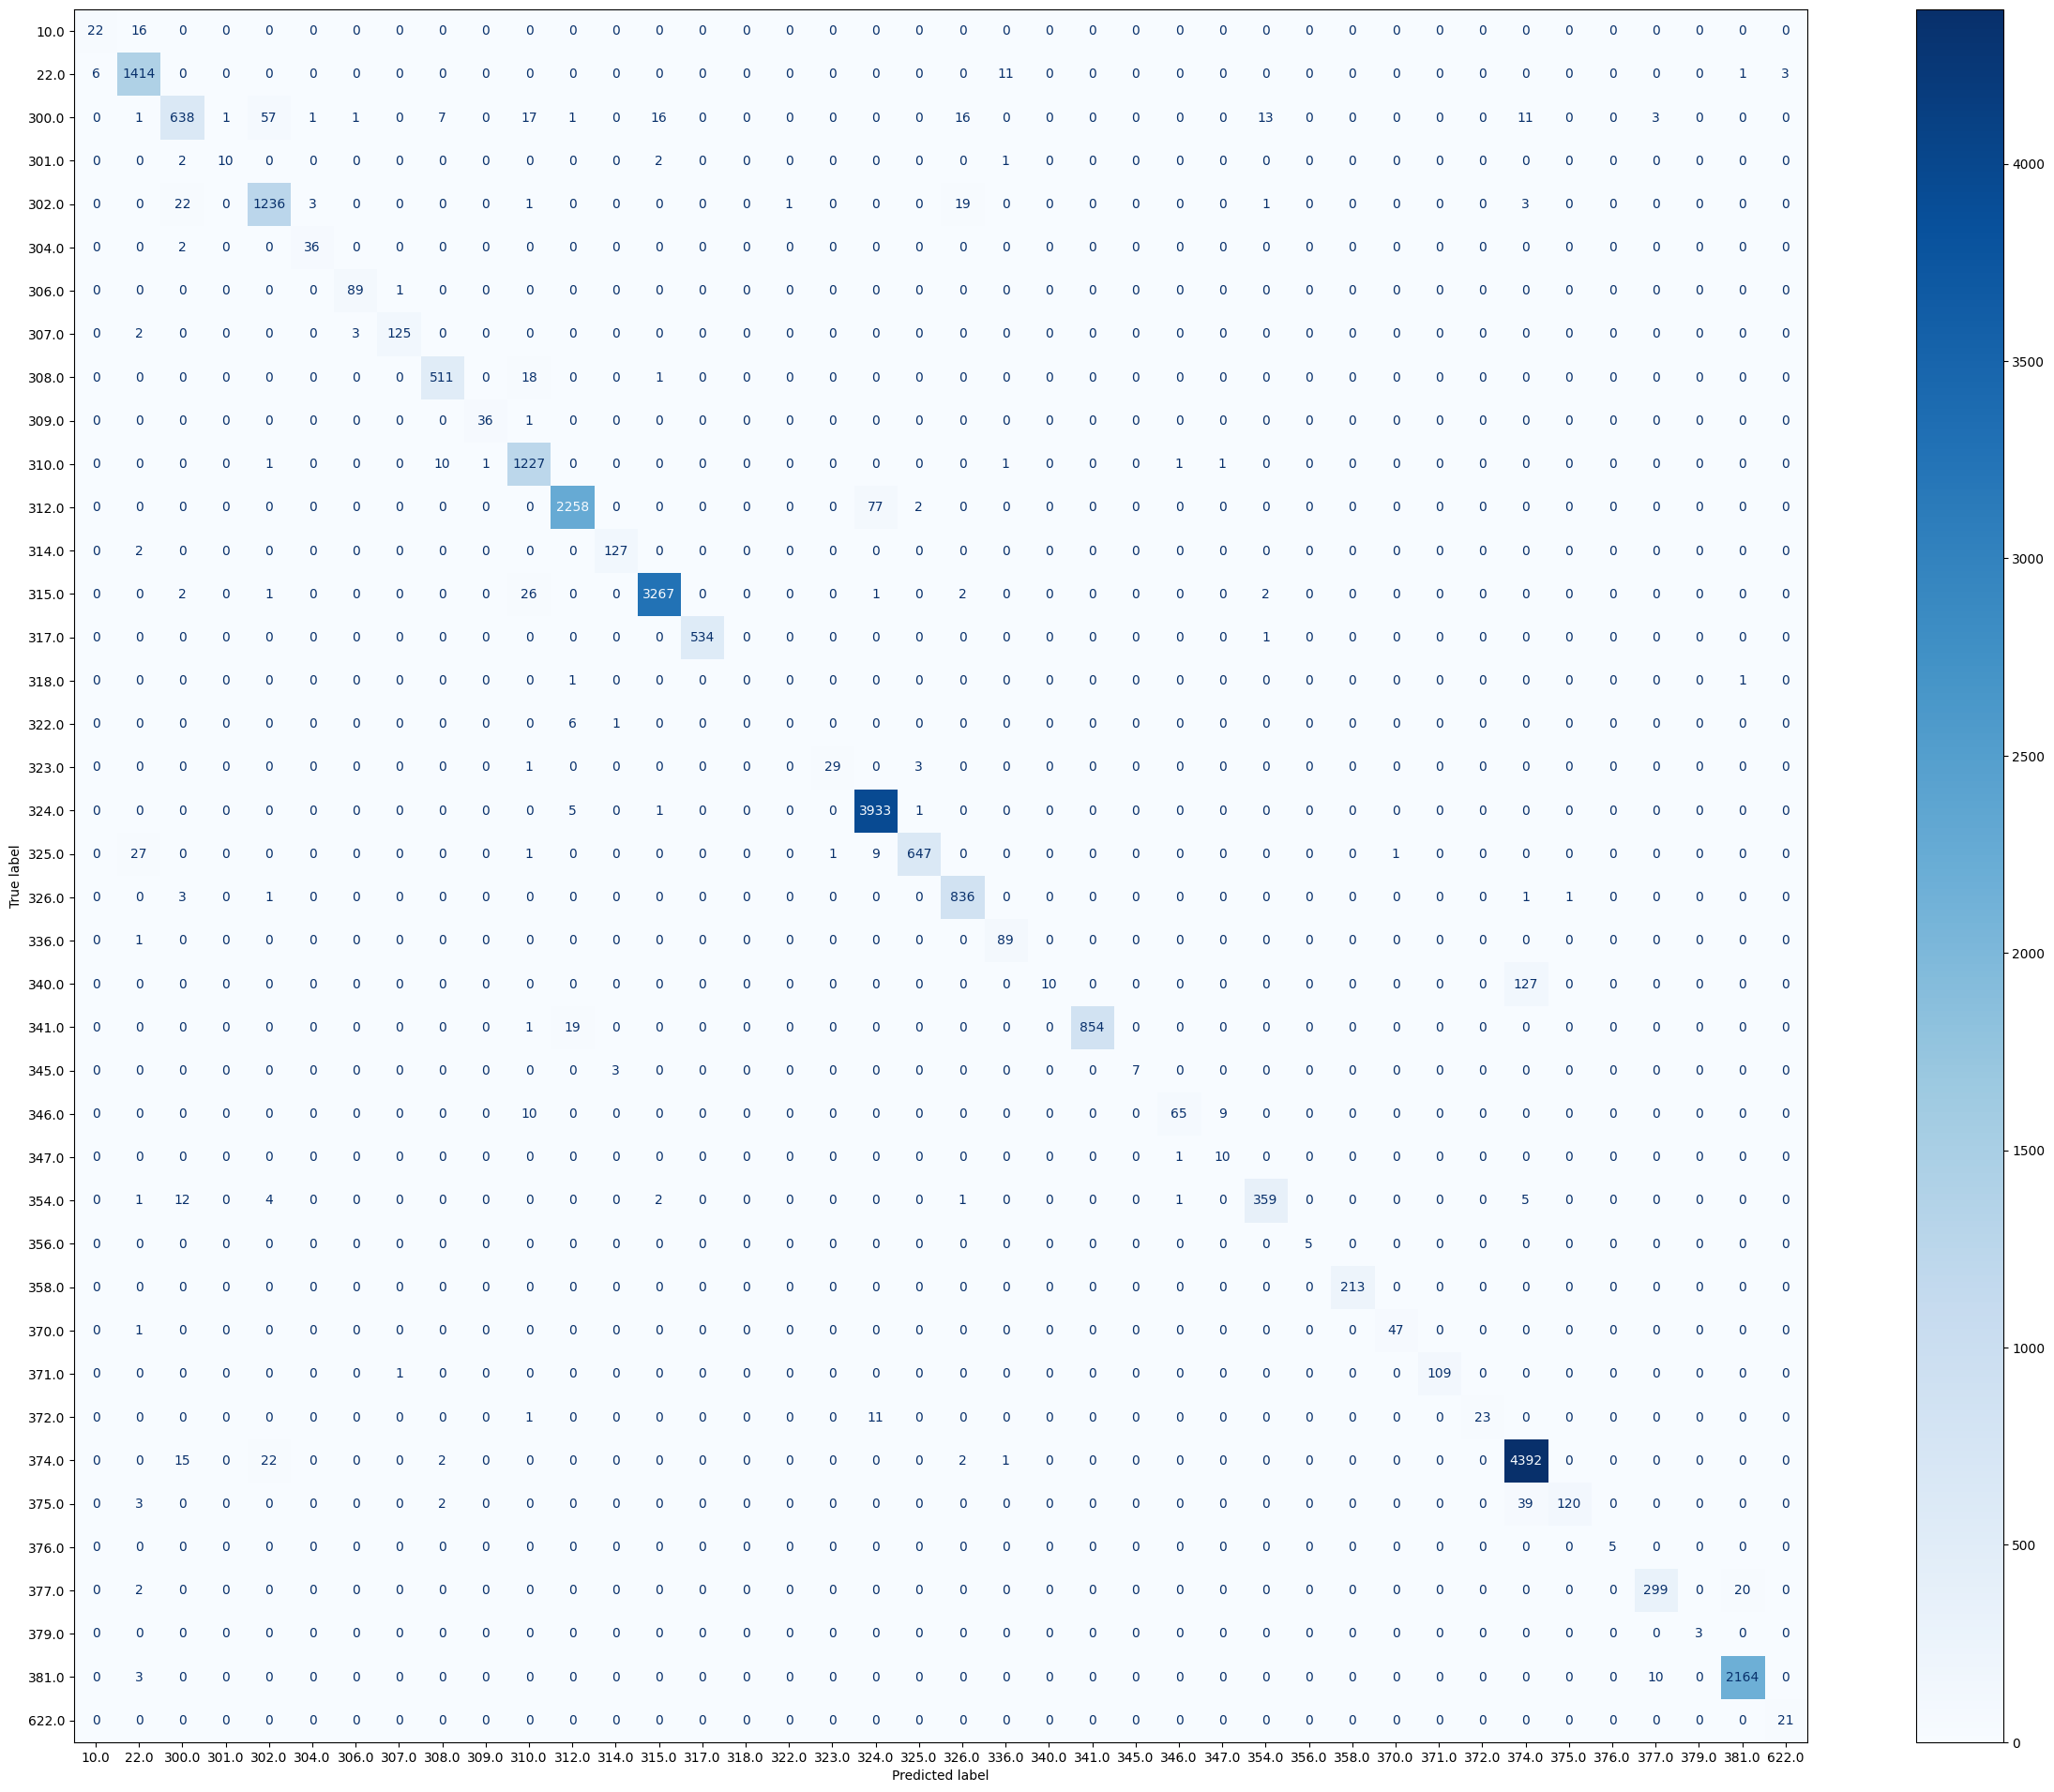

In [ ]:
cm = confusion_matrix(y_test, y_pred)
class_labels = rf_classifier.classes_

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
fig, ax = plt.subplots(figsize=(30, 24))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.show()

### Balanced dataset

A second model was then trained on the balanced dataset, retaining the same hyperparameters.

In [ ]:
X = data_600_encoded.drop(columns=['IvaM'])
y = data_600_encoded['IvaM']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
rf_classifier = RandomForestClassifier(max_depth=None, min_samples_leaf= 1, min_samples_split= 2, n_estimators=150)
rf_classifier.fit(X_train, y_train)
y_pred = rf_classifier.predict(X_test)

In [ ]:
rf_metrics(y_test, y_pred)

Accuracy: 0.9696193953996161
Precision: 0.9698039849509005
Recall: 0.9696193953996161
F1 Score: 0.9673020936833089
Classification Report:
              precision    recall  f1-score   support

        22.0       0.96      0.98      0.97      1435
        99.0       0.94      0.92      0.93       812
       300.0       0.91      0.81      0.86       783
       302.0       0.93      0.96      0.95      1286
       308.0       0.96      0.97      0.96       530
       310.0       0.94      0.98      0.96      1242
       312.0       0.99      0.97      0.98      2337
       314.0       0.98      0.98      0.98       129
       315.0       0.99      0.99      0.99      3301
       317.0       1.00      1.00      1.00       535
       324.0       0.98      1.00      0.99      3940
       325.0       0.99      0.94      0.97       686
       326.0       0.96      0.99      0.97       842
       340.0       1.00      0.07      0.14       137
       341.0       1.00      0.98      0.99       8

We also implemented 5-fold cross validation, with accuracy as a scoring metric to further evaluate the trained model.

In [ ]:
scores = cross_val_score(rf_classifier, X_train, y_train, cv=5)

print("Accuracy scores for each fold:", scores)
print("Mean cross-validation accuracy:", scores.mean())

Accuracy scores for each fold: [0.97002494 0.97002353 0.96842353 0.96832941 0.96790588]
Mean cross-validation accuracy: 0.9689414585887999


In [ ]:
scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')  # For multi-class classification

print("F1 scores for each fold:", scores)
print("Mean F1 score:", scores.mean())

F1 scores for each fold: [0.92167966 0.91801508 0.92277321 0.92247534 0.91748808]
Mean F1 score: 0.9204862747959461


We also include the random forest model's capability of classifying the classes in class 99 (classes with less than 600 values). We filtered the test dataset for class 99, then computed the metrics, most notably the accuracy score. It did not differ from the accuracy score of classification of class 99 obtained from the decision tree score.

In [ ]:
replacement_value = (y_test == 99.0)

y_pred_class_99 = y_pred[replacement_value]
y_true_class_99 = y_test[replacement_value]

rf_metrics(y_true_class_99, y_pred_class_99)

Accuracy: 0.9199507389162561
Precision: 1.0
Recall: 0.9199507389162561
F1 Score: 0.9583066067992302
Classification Report:
              precision    recall  f1-score   support

        22.0       0.00      0.00      0.00         0
        99.0       1.00      0.92      0.96       812
       300.0       0.00      0.00      0.00         0
       310.0       0.00      0.00      0.00         0
       312.0       0.00      0.00      0.00         0
       314.0       0.00      0.00      0.00         0
       315.0       0.00      0.00      0.00         0
       324.0       0.00      0.00      0.00         0
       325.0       0.00      0.00      0.00         0
       354.0       0.00      0.00      0.00         0
       374.0       0.00      0.00      0.00         0
       381.0       0.00      0.00      0.00         0

    accuracy                           0.92       812
   macro avg       0.08      0.08      0.08       812
weighted avg       1.00      0.92      0.96       812

Confusion 

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarni

We again included a more interpretable confusion matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)
class_labels = rf_classifier.classes_

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
fig, ax = plt.subplots(figsize=(24, 18))
disp.plot(cmap=plt.cm.Blues, ax=ax)  # Use ax parameter to specify the axis
plt.show()

###Tree Visualization

Here below we can see a Tree Visualization of our model. While the visualization might appear cluttered due to the complexity of the tree, it serves as a helpful visual aid for understanding how the model performs the classification task.

In [ ]:
class_names = y.unique().astype(str)
estimator = rf_classifier.estimators_[10]

# Generate the dot data for visualization
dot_data = export_graphviz(
    estimator, out_file=None,
    feature_names=X_train.columns,
    class_names=class_names,
    rounded=True, proportion=False,
    precision=2, filled=True
)

# Generate the graph
graph = graphviz.Source(dot_data)
graph.format = 'png'
graph.render("tree", view=False)  # Save and do not attempt to open

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.17791 to fit


'tree.png'

# UI Interface

This is the showcase of our code. The necessary libraries have been installed in the beginning of the program.

Please ensure that the .py file (app1.py) is located in the same directory as this code.

A local tunnel will be generated, indicated by 'your url is:'

When clicking on generated url, copy and paste the first line of returned (IP address) into the tunnel password box.

This will lead to our UI interface, in which a user may choose the values of the feature variables, and the predicted IvaM value will be returned.

In [ ]:
!streamlit run app1.py &>/content/logs.txt & npx localtunnel --port 8501 & curl ipv4.icanhazip.com

35.229.69.171
npx: installed 22 in 3.857s
your url is: https://hip-maps-invent.loca.lt


In [30]:
pip freeze > requirements.txt